# Predicción de Salario

In [1]:
# importando las principales librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

- **work_year**: El año en que se pagó el salario.

- **experience_level**: El nivel de experiencia en el trabajo durante el año, con los siguientes valores posibles: 
    - EN Nivel de entrada / Junior 
    - MI Nivel medio / Intermedio 
    - SE Nivel senior / Experto 
    - EX Nivel ejecutivo / Director


- **employment_type**: El tipo de empleo para el puesto: 
    - PT Medio tiempo 
    - FT Tiempo completo 
    - CT Contrato 
    - FL Freelance


- **job_title**: El cargo desempeñado durante el año.

- **salary**: El monto total del salario bruto pagado.

- **salary_currency**: La moneda en la que se pagó el salario, según el código de moneda ISO 4217.

- **salary_in_usd**: El salario convertido a dólares estadounidenses (USD), usando la tasa de cambio promedio del año correspondiente (según fxdata.foorilla.com).

- **employee_residence**: País de residencia principal del empleado durante el año laboral, según el código de país ISO 3166.

- **remote_ratio**: Porcentaje de trabajo realizado de forma remota, con los siguientes valores posibles: 
    - 0 Sin trabajo remoto (menos del 20%)
    - 50 Parcialmente remoto 
    - 100 Totalmente remoto (más del 80%)
    
- **company_location**: País de la oficina principal del empleador o sucursal contratante, según el código de país ISO 3166.

- **company_size**: Número promedio de empleados en la empresa durante el año: 
    - S Menos de 50 empleados (pequeña)
    - M Entre 50 y 250 empleados (mediana)
    - L Más de 250 empleados (grande)

### Extayendo los datos de Kaggle

In [2]:
path_kaggle = kagglehub.dataset_download("ruchi798/data-science-job-salaries")
path_csv = os.path.join(path_kaggle, "ds_salaries.csv")
df_salaries = pd.read_csv(path_csv)
df_salaries.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


### información general de los datos

In [3]:
df_salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


### cantidad de valores nulos

In [4]:
df_salaries.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

### estadísticas descriptivas de las variables numéricas

In [5]:
df_salaries.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


### estadísticas descriptivas de las variables categóricas

In [6]:
columnas_cat = df_salaries.select_dtypes(exclude="int64").columns
df_salaries[columnas_cat] = df_salaries[columnas_cat].astype("category")
df_salaries.describe(include="category")

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,607,607,607,607,607,607,607
unique,4,4,50,17,57,50,3
top,SE,FT,Data Scientist,USD,US,US,M
freq,280,588,143,398,332,355,326


### conversión a tipo categórico y reordenamiento

In [7]:
df_salaries["experience_level"] = df_salaries["experience_level"].cat.reorder_categories(["EN","MI","SE","EX"], ordered=True)

### clasificación de los grupos de teatro

In [8]:
conditions = [
    df_salaries["job_title"].str.contains("Data Scientest", case=False),
    df_salaries["job_title"].str.contains("Data Engineer", case=False),
    df_salaries["job_title"].str.contains("Analyst", case=False),
    df_salaries["job_title"].str.contains("Machine Learning|ML", case=False),
    df_salaries["job_title"].str.contains("Computer Vision", case=False),
    df_salaries["job_title"].str.contains("Architect", case=False),
    df_salaries["job_title"].str.contains("Manager|Head|Director|Lead|Principal|Staff", case=False)    
]

choices = [
    "Data Scientist",
    "Data Engineer",
    "Data Analyst",
    "ML Engineer",
    "CV Engineer",
    "Data Architect",
    "Data Leader"
]

df_salaries["job_group"] = np.select(conditions, choices, default="Other")
df_salaries = df_salaries.drop(['salary', 'salary_currency', 'Unnamed: 0','job_title'], axis=1)

### agrupación de los países por continente

In [9]:
continent_map = {
    'US': 'North America', 'CA': 'North America', 'MX': 'North America',
    'BR': 'South America', 'CL': 'South America', 'AR': 'South America', 'BO': 'South America',
    'GB': 'Europe', 'DE': 'Europe', 'FR': 'Europe', 'ES': 'Europe', 'IT': 'Europe',
    'PL': 'Europe', 'NL': 'Europe', 'GR': 'Europe', 'PT': 'Europe', 'RU': 'Europe',
    'AT': 'Europe', 'DK': 'Europe', 'IE': 'Europe', 'CH': 'Europe', 'EE': 'Europe',
    'IN': 'Asia', 'PK': 'Asia', 'SG': 'Asia', 'JP': 'Asia', 'VN': 'Asia', 'TR': 'Asia', 'AE': 'Asia', 'CN': 'Asia',
    'NG': 'Africa',
    'AU': 'Oceania'
}

df_salaries["residence_group"] = df_salaries["employee_residence"].map(continent_map)
df_salaries["residence_group"] = df_salaries["residence_group"].fillna("Other")

df_salaries["company_group"] = df_salaries["company_location"].map(continent_map)
df_salaries["company_group"] = df_salaries["company_group"].fillna("Other")

df_salaries = df_salaries.drop(["employee_residence","company_location"], axis=1)

In [10]:
df_salaries_copy = df_salaries.copy()

### eliminando outliers

In [11]:
print(f"Número de casos (observaciones): {df_salaries_copy.shape[0]}")

Número de casos (observaciones): 607


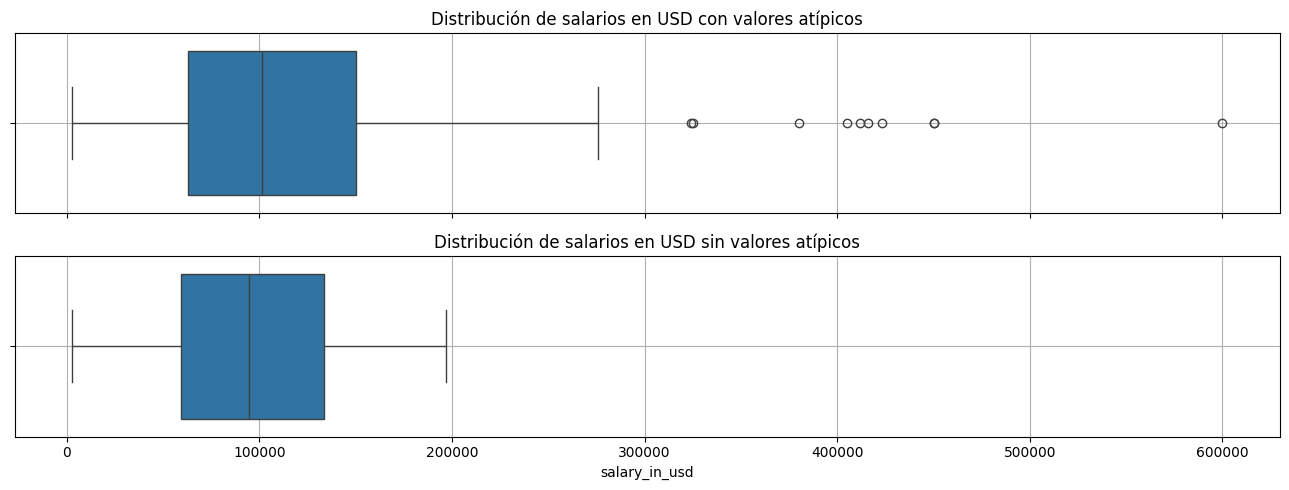

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(13,5), sharex=True)
sns.boxplot(x=df_salaries_copy["salary_in_usd"], ax=ax[0])
ax[0].set_title("Distribución de salarios en USD con valores atípicos")
ax[0].grid(True)
sns.boxplot(x=df_salaries_copy[df_salaries["salary_in_usd"] < df_salaries["salary_in_usd"].quantile(0.9)]["salary_in_usd"], ax=ax[1])
ax[1].set_title("Distribución de salarios en USD sin valores atípicos")
ax[1].grid(True)
plt.tight_layout()
plt.show()


In [13]:
df_salaries_copy = df_salaries_copy[df_salaries["salary_in_usd"] < df_salaries["salary_in_usd"].quantile(0.9)]
print(f"Número de casos (observaciones): {df_salaries_copy.shape[0]}")

Número de casos (observaciones): 543


### estadísticas descriptivas de la variable objetivo ```salary_in_usd```

In [14]:
df_salaries_copy["salary_in_usd"].describe().round(2)

count       543.00
mean      95774.20
std       47853.59
min        2859.00
25%       59102.00
50%       94564.00
75%      133660.00
max      196979.00
Name: salary_in_usd, dtype: float64

In [15]:
# df_salaries_copy["experience_level"] = pd.to_numeric(df_salaries_copy["experience_level"], errors="coerce")

In [16]:
df_salaries_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 543 entries, 0 to 605
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   work_year         543 non-null    int64   
 1   experience_level  543 non-null    category
 2   employment_type   543 non-null    category
 3   salary_in_usd     543 non-null    int64   
 4   remote_ratio      543 non-null    int64   
 5   company_size      543 non-null    category
 6   job_group         543 non-null    object  
 7   residence_group   543 non-null    object  
 8   company_group     543 non-null    object  
dtypes: category(3), int64(3), object(3)
memory usage: 31.8+ KB


In [17]:
columns_num = df_salaries_copy.select_dtypes(include="int64").columns.drop('salary_in_usd')
columns_cat = df_salaries_copy.select_dtypes(exclude="int64").columns

In [18]:
print(df_salaries_copy.dtypes)
print(df_salaries_copy['experience_level'].unique())


work_year              int64
experience_level    category
employment_type     category
salary_in_usd          int64
remote_ratio           int64
company_size        category
job_group             object
residence_group       object
company_group         object
dtype: object
['MI', 'SE', 'EN', 'EX']
Categories (4, object): ['EN' < 'MI' < 'SE' < 'EX']


## Codificación de las variables categóricas

In [19]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
vars_ohe = ohe.fit_transform(df_salaries_copy[["experience_level","employment_type","job_group","residence_group","company_group","company_size"]])

df_salaries_copy[ohe.get_feature_names_out()] = vars_ohe
df_salaries_copy = df_salaries_copy.drop(["experience_level","employment_type","job_group","residence_group","company_group","company_size"],axis=1)


## Separando las variables de entrenamiento y prueba

In [20]:
X = df_salaries_copy.drop("salary_in_usd", axis=1)
y = df_salaries_copy["salary_in_usd"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### estandarizando los valores de la variable independiente

In [22]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train_sc = sc_X.fit_transform(X_train)
X_test_sc = sc_X.transform(X_test)

X_train_sc_df = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc_df = pd.DataFrame(X_test_sc, columns=X.columns)

## Creando el modelo de ```RandomForestRegressor```
### optimizando hiperparámetros con ```GridSearchCV```

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

model_rf = RandomForestRegressor(random_state=42)
# grilla de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# configurando gridsearchcv
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid,
                           cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_sc_df, y_train)
best_rf = grid_search.best_estimator_
# predicciones
y_pred = best_rf.predict(X_test_sc_df)
# métricas
mae= mean_absolute_error(y_test, y_pred)
rmse= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

print("Mejor combinación de hiperparámetros:")
print(grid_search.best_params_)
print("\nResultados del modelo optimizado:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.5f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejor combinación de hiperparámetros:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Resultados del modelo optimizado:
MAE: 24729.74
RMSE: 1009894707.02
R2: 0.55209


## SHAP (SHapley Additive exPlanations)

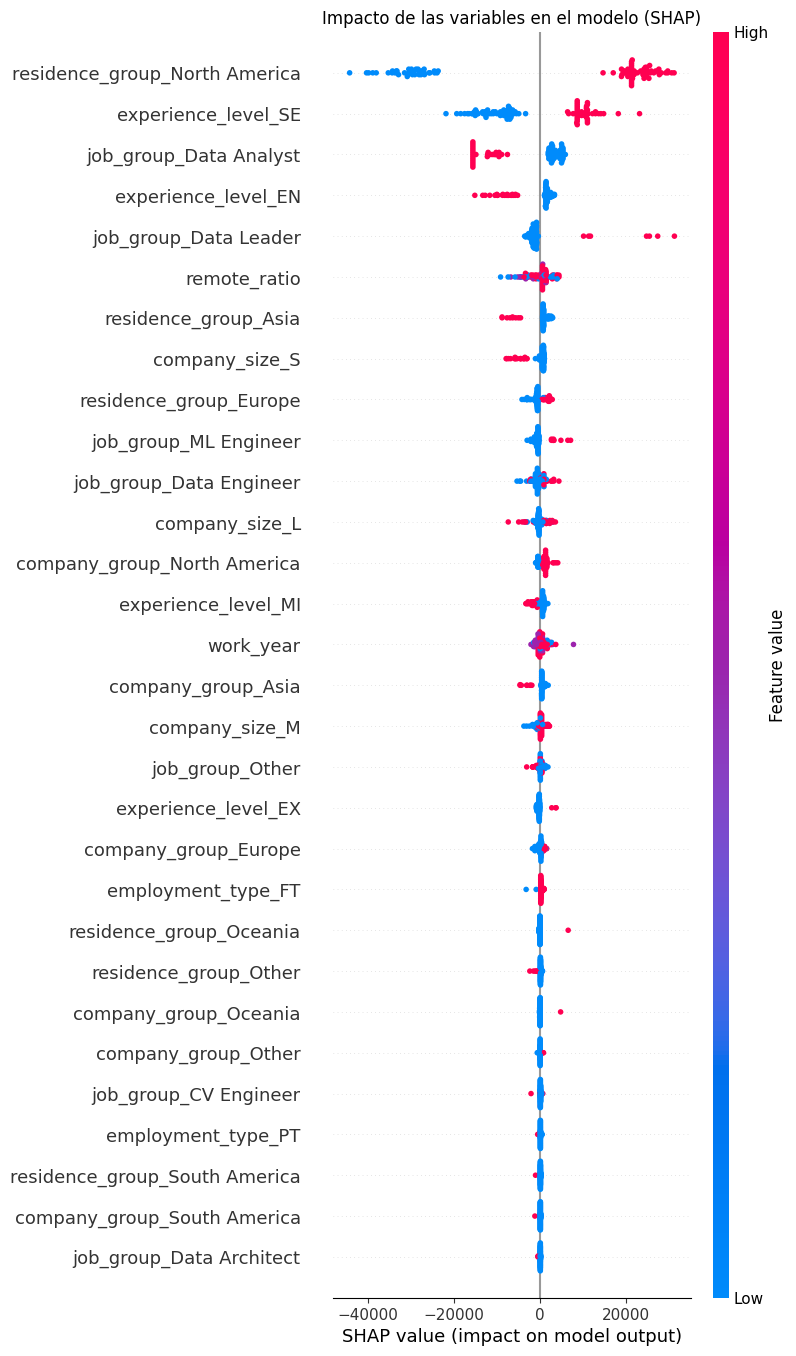

In [24]:
tree_explainer = shap.TreeExplainer(best_rf)
shap_values = tree_explainer.shap_values(X_test_sc_df)
shap.summary_plot(shap_values, X_test_sc_df, show=False, max_display=30)
plt.title("Impacto de las variables en el modelo (SHAP)")
plt.show()

## Interpretación del gráfico

 - **residence_group_North America:** Vivir en Norteamérica tiene un gran impacto positivo en el salario (puntos rojos a la derecha).

- **experience_level_SE (nivel senior):**  Mayor experiencia (rojo) aumenta el salario, menor experiencia (azul) lo reduce.

- **job_group_Data Analyst:** Tiende a tener impacto negativo (muchos puntos a la izquierda), indicando que este rol reduce el salario.

- **experience_level_EN (nivel junior):**  Menor experiencia (rojo) reduce el salario, mayor experiencia (azul) lo aumenta.

- **job_group_Data Leader:** Impacto positivo (puntos rojos a la derecha), sugiere que roles de liderazgo aumentan el salario.

Variables como **remote_ratio** y **company_size** también influyen, pero menos que las anteriores.

In [25]:
# media del impacto por cada variable en la predicción
shap_df = pd.DataFrame(shap_values, columns=X_test_sc_df.columns)
mean_importance = shap_df.abs().mean().sort_values(ascending=False)

## Pipeline para elegir las variables como mejor impacto en el modelo de regresión

La iteración 1 se queda con 34 variables
La iteración 2 se queda con 30 variables
[{'iteracion': 1, 'variables': 34, 'MAE': 24729.74, 'RMSE': np.float64(31778.84), 'R2': 0.5521, 'Mejores parámetros': {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}}, {'iteracion': 2, 'variables': 30, 'MAE': 24704.39, 'RMSE': np.float64(31763.45), 'R2': 0.5525, 'Mejores parámetros': {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}}]
Variables seleccionadas:
['work_year', 'remote_ratio', 'experience_level_EN', 'experience_level_EX', 'experience_level_MI', 'experience_level_SE', 'employment_type_FT', 'employment_type_PT', 'job_group_CV Engineer', 'job_group_Data Analyst', 'job_group_Data Architect', 'job_group_Data Engineer', 'job_group_Data Leader', 'job_group_ML Engineer', 'job_group_Other', 'residence_group_Asia', 'residence_group_Europe', 'residence_group_North America', 'residence_group_Oceania', 'residence_group_Other', 'resid

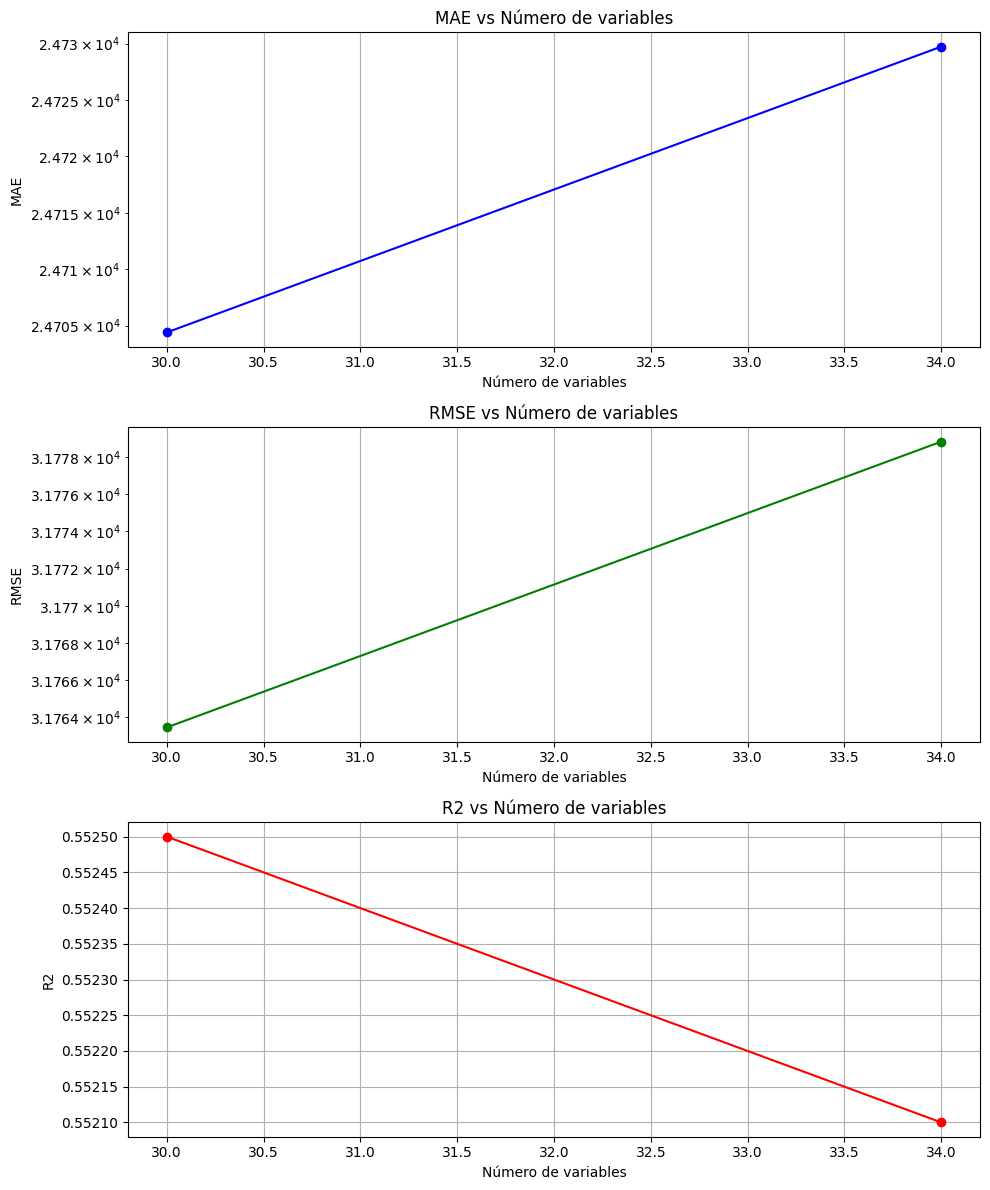

In [26]:
# grilla de hiperparámetros
param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1,2]
}
# umbral de decision
# tomando los impactos que superen el 1% de la media del impacto
umbral = mean_importance.mean()*0.01
# iniciando con todas las variables
results = []
variables_restantes = X_train_sc_df.columns
iteracion = 0
while True:
    iteracion += 1
    print(f"La iteración {iteracion} se queda con {len(variables_restantes)} variables")
    # variables restantes
    X_train_rest = X_train_sc_df[variables_restantes]
    X_test_rest = X_test_sc_df[variables_restantes]
    # aplicando gridsearchcv
    grid_1 = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=3, n_jobs=-1)
    grid_1.fit(X_train_rest, y_train)
    best_rf_1 = grid_1.best_estimator_
    # predicciones
    y_pred_1 = best_rf_1.predict(X_test_rest)
    # métricas
    mae_1 = round(mean_absolute_error(y_test, y_pred_1),2)
    rmse_1 = round(np.sqrt(mean_squared_error(y_test, y_pred_1)),2)
    r2_1 = round(r2_score(y_test, y_pred_1),4)
    # SHAP
    tree_explainer = shap.TreeExplainer(best_rf_1)
    shap_values = tree_explainer.shap_values(X_train_rest)
    shap_df = pd.DataFrame(shap_values, columns=variables_restantes)
    mean_importances = shap_df.abs().mean()
    # guardando resultados
    results.append({
        "iteracion": iteracion,
        "variables": len(variables_restantes),
        "MAE": mae_1,
        "RMSE": rmse_1,
        "R2": r2_1,
        "Mejores parámetros": grid_1.best_params_
    })
    # eliminando variables que se encuentran debajo del umbral
    vars_bajo_impacto = mean_importances[mean_importance < umbral].index.tolist()
    if not vars_bajo_impacto: # si la lista de variables que se va a eliminar esta vacía se detiene ahí
        break
    variables_restantes = [var for var in variables_restantes if var not in vars_bajo_impacto]

results_df = pd.DataFrame(results)
print(results)
# gráfica de las métricas
fig, axs = plt.subplots(3, 1, figsize=(10, 12))
# MAE
axs[0].plot(results_df["variables"], results_df["MAE"], marker='o', color='blue')
axs[0].set_title("MAE vs Número de variables")
axs[0].set_xlabel("Número de variables")
axs[0].set_ylabel("MAE")
axs[0].set_yscale("log")
axs[0].grid(True)
# RMSE
axs[1].plot(results_df["variables"], results_df["RMSE"], marker='o', color='green')
axs[1].set_title("RMSE vs Número de variables")
axs[1].set_xlabel("Número de variables")
axs[1].set_ylabel("RMSE")
axs[1].set_yscale("log")
axs[1].grid(True)
# R2
axs[2].plot(results_df["variables"], results_df["R2"], marker='o', color='red')
axs[2].set_title("R2 vs Número de variables")
axs[2].set_xlabel("Número de variables")
axs[2].set_ylabel("R2")
axs[2].grid(True)
plt.tight_layout()
print("Variables seleccionadas:")
print(variables_restantes)

### - **Primer subplot (MAE):** Escala logarítmica para visualizar diferencias aunque sean pequeñas.
### - **Segundo subplot (RMSE):** Escala logarítmica, dado que sus valores son muy grandes.
### - **Tercer subplot (R2):** Escala lineal, ya que está entre 0 y 1. Se muestra una mejora al eliminar una variable.

## Comparación de distribuciones: predicciones vs. valores reales (train/test)

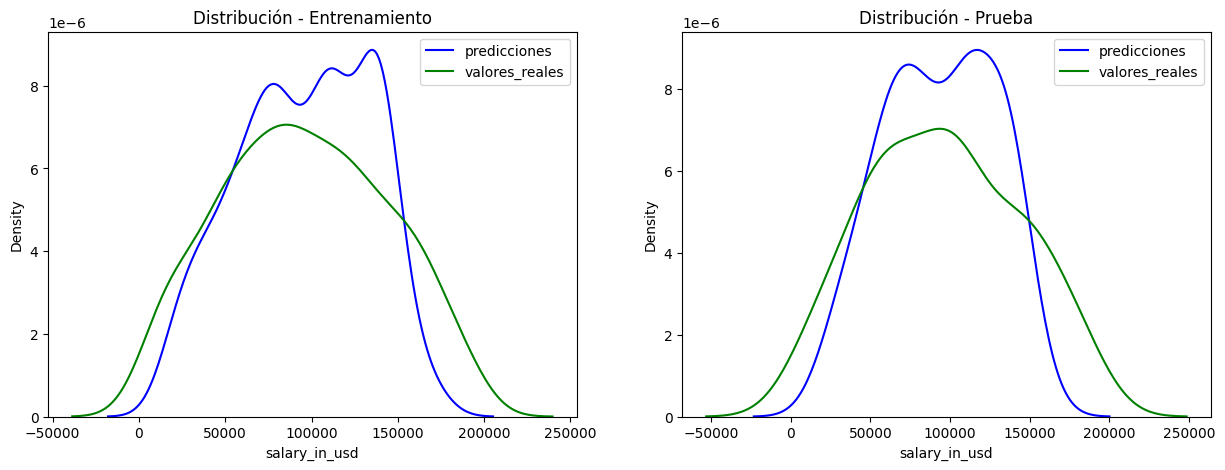

In [27]:
prediccion_train = best_rf_1.predict(X_train_sc_df[variables_restantes])
prediccion_test = best_rf_1.predict(X_test_sc_df[variables_restantes])

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.kdeplot(prediccion_train, color="blue", label="predicciones", ax=ax[0])
sns.kdeplot(y_train, color="green", label="valores_reales", ax=ax[0])
ax[0].set_title("Distribución - Entrenamiento")
ax[0].legend()

sns.kdeplot(prediccion_test, color="blue", label="predicciones", ax=ax[1])
sns.kdeplot(y_test, color="green", label="valores_reales", ax=ax[1])
ax[1].set_title("Distribución - Prueba")
ax[1].legend()
plt.show()